# Phase 2 Stage-2 training

In [1]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
from torch.optim import AdamW
from torchvision.models import efficientnet_b2
from sklearn.metrics import (f1_score, precision_score,
                              recall_score, classification_report,
                              confusion_matrix)
import matplotlib.pyplot as plt
from tqdm import tqdm

print("PyTorch  :", torch.__version__)
print("CUDA     :", torch.cuda.is_available())

PyTorch  : 2.10.0+cu128
CUDA     : True


In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paste the exact folder name you saw in os.listdir("/kaggle/input")
BASE_PATH       = "/kaggle/working"
DATA_PATH       = "/kaggle/input/ecg-processed-data"
STAGE1_CKPT_DIR = "/kaggle/input/ecg-processed-data"
CKPT_DIR        = "/kaggle/working/checkpoints_stage2"
os.makedirs(CKPT_DIR, exist_ok=True)

CKPT_MODEL   = os.path.join(CKPT_DIR, "best_model.pt")
CKPT_STATE   = os.path.join(CKPT_DIR, "train_state.json")
HISTORY_PATH = os.path.join(CKPT_DIR, "history.json")

print("Device         :", DEVICE)
print("Data path      :", DATA_PATH)
print("Stage2 ckpt dir:", CKPT_DIR)

Device         : cuda
Data path      : /kaggle/input/ecg-processed-data
Stage2 ckpt dir: /kaggle/working/checkpoints_stage2


## Hyperparameters

In [3]:
BATCH_SIZE   = 32        # EfficientNet-B2 is heavier than TCN, keep at 32
LR           = 5e-4
WEIGHT_DECAY = 1e-3
MAX_EPOCHS   = 100
PATIENCE     = 15
WARMUP_EPOCHS= 5         # CrossEntropy for first 5 epochs, then Focal Loss
VAL_FRAC     = 0.15
SEED         = 42

# Focal loss parameters (AF=3×, Other=1×, Noisy=5×)
FOCAL_GAMMA  = 2.0
FOCAL_ALPHA  = [3.0, 1.0, 5.0]   # per-class weights: A→0, O→1, ~→2

# MixUp
MIXUP_ALPHA  = 0.2

CLASS_NAMES  = ["AF (A)", "Other (O)", "Noisy (~)"]


## Load spectogram from phase 1

In [5]:
print("Loading spectrograms...")
train_data = np.load("/kaggle/input/datasets/anora7/ecg-processed-data/train_spectro.npz", allow_pickle=True)
test_data  = np.load("/kaggle/input/datasets/anora7/ecg-processed-data/test_spectro.npz",  allow_pickle=True)
 
X_train = train_data["spectrograms"]
y_train = train_data["labels"]
X_test  = test_data["spectrograms"]
y_test  = test_data["labels"]
 
print(f"Train spectrograms : {X_train.shape}  labels: {y_train.shape}")
print(f"Test  spectrograms : {X_test.shape}   labels: {y_test.shape}")
print("Train class counts:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {(y_train == i).sum()}")
print("Test class counts:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {(y_test == i).sum()}")
 

Loading spectrograms...
Train spectrograms : (18376, 3, 224, 224)  labels: (18376,)
Test  spectrograms : (1454, 3, 224, 224)   labels: (1454,)
Train class counts:
  AF (A): 3712
  Other (O): 13800
  Noisy (~): 864
Test class counts:
  AF (A): 307
  Other (O): 1067
  Noisy (~): 80


## DataLoaders

In [6]:
def make_loaders(X, y, val_frac, batch_size, seed):
    n_val     = int(val_frac * len(y))
    n_train   = len(y) - n_val
 
    rng       = np.random.default_rng(seed)
    indices   = rng.permutation(len(y))
    train_idx = indices[:n_train]
    val_idx   = indices[n_train:]
 
    train_loader = DataLoader(
        list(zip(X[train_idx], y[train_idx])),
        batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True,
        collate_fn=lambda batch: (
            torch.tensor(np.stack([b[0] for b in batch]), dtype=torch.float32),
            torch.tensor(np.array([b[1] for b in batch]), dtype=torch.long)
        )
    )
    val_loader = DataLoader(
        list(zip(X[val_idx], y[val_idx])),
        batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True,
        collate_fn=lambda batch: (
            torch.tensor(np.stack([b[0] for b in batch]), dtype=torch.float32),
            torch.tensor(np.array([b[1] for b in batch]), dtype=torch.long)
        )
    )
    return train_loader, val_loader, n_train, n_val
 
train_loader, val_loader, n_train, n_val = make_loaders(
    X_train, y_train, VAL_FRAC, BATCH_SIZE, SEED)
 
print(f"Train windows : {n_train}")
print(f"Val windows   : {n_val}")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train windows : 15620
Val windows   : 2756
Train batches : 489
Val batches   : 87


## MixUp helper

In [7]:
def mixup_batch(x, y, alpha=MIXUP_ALPHA):
    """Returns mixed inputs and both label sets + lambda. Applied in train loop."""
    lam   = np.random.beta(alpha, alpha)
    perm  = torch.randperm(x.size(0), device=x.device)
    x_mix = lam * x + (1 - lam) * x[perm]
    y_a, y_b = y, y[perm]
    return x_mix, y_a, y_b, lam



## Focal Loss

In [8]:
def focal_loss(logits, targets, gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA):
    """
    Multi-class focal loss.
    alpha : per-class weight list, length = num_classes
    gamma : focusing parameter
    """
    alpha_t  = torch.tensor(alpha, dtype=torch.float32, device=logits.device)
    ce_loss  = F.cross_entropy(logits, targets, weight=alpha_t, reduction="none")
    pt       = torch.exp(-ce_loss)
    fl       = ((1 - pt) ** gamma) * ce_loss
    return fl.mean()


def mixup_focal_loss(logits, y_a, y_b, lam,
                     gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA):
    loss_a = focal_loss(logits, y_a, gamma, alpha)
    loss_b = focal_loss(logits, y_b, gamma, alpha)
    return lam * loss_a + (1 - lam) * loss_b


## Build EfficientNet-B2

In [9]:
def build_stage2_efficientnet(dropout=0.4):
    """
    EfficientNet-B2 pretrained on ImageNet.
    Input  : (batch, 3, 224, 224)  — 3-channel spectrograms
    Output : (batch, 3)            — AF / Other / Noisy logits
    """
    model = efficientnet_b2(weights="IMAGENET1K_V1")

    # Replace classifier head: 1408 → 3
    in_features = model.classifier[1].in_features   # 1408
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, 3)
    )
    return model


def forward_stage2(model, x):
    """Plain forward — EfficientNet handles its own reshape internally."""
    return model(x)

In [10]:
# ── Cell 10 : Instantiate model ───────────────────────────────────────
model = build_stage2_efficientnet(dropout=0.4).to(DEVICE)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params= sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 154MB/s] 


Total params    : 7,705,221
Trainable params: 7,705,221


In [11]:
# ── Cell 11 : Optimiser and scheduler ────────────────────────────────
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Warmup loss (used for first WARMUP_EPOCHS epochs)
warmup_criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(FOCAL_ALPHA, dtype=torch.float32).to(DEVICE)
)

# Linear warmup → cosine decay scheduler
def get_scheduler(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs       # linear warmup
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return 0.5 * (1.0 + np.cos(np.pi * progress))  # cosine decay
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler = get_scheduler(optimizer, WARMUP_EPOCHS, MAX_EPOCHS)

print("Optimiser : AdamW  lr=5e-4  weight_decay=1e-3")
print(f"Scheduler : linear warmup ({WARMUP_EPOCHS} epochs) → cosine decay")
print(f"Loss      : CrossEntropy (warmup) → FocalLoss gamma={FOCAL_GAMMA} alpha={FOCAL_ALPHA}")


Optimiser : AdamW  lr=5e-4  weight_decay=1e-3
Scheduler : linear warmup (5 epochs) → cosine decay
Loss      : CrossEntropy (warmup) → FocalLoss gamma=2.0 alpha=[3.0, 1.0, 5.0]


In [12]:
# ── Cell 12 : Checkpoint helpers ─────────────────────────────────────
def save_checkpoint(model, optimizer, scheduler, epoch,
                    best_val_f1, patience_ctr, history):
    torch.save(model.state_dict(), CKPT_MODEL)
    state = {
        "epoch":        epoch,
        "best_val_f1":  best_val_f1,
        "patience_ctr": patience_ctr,
        "lr":           optimizer.param_groups[0]["lr"],
    }
    with open(CKPT_STATE, "w") as f:
        json.dump(state, f)
    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f)


def load_checkpoint(model, optimizer, scheduler):
    if not os.path.exists(CKPT_MODEL) or not os.path.exists(CKPT_STATE):
        print("No Stage 2 checkpoint found. Starting from scratch.")
        return 0, 0.0, 0, {"train": [], "val": []}
    model.load_state_dict(torch.load(CKPT_MODEL, map_location=DEVICE))
    with open(CKPT_STATE) as f:
        state = json.load(f)
    for pg in optimizer.param_groups:
        pg["lr"] = state["lr"]
    history = {"train": [], "val": []}
    if os.path.exists(HISTORY_PATH):
        with open(HISTORY_PATH) as f:
            history = json.load(f)
    # Replay scheduler steps so cosine position is correct
    for _ in range(state["epoch"] + 1):
        scheduler.step()
    print(f"Resumed from epoch {state['epoch'] + 1}  "
          f"best val F1: {state['best_val_f1']:.4f}")
    return state["epoch"] + 1, state["best_val_f1"], state["patience_ctr"], history

In [13]:
# ── Cell 13 : Metrics helpers ─────────────────────────────────────────
def compute_metrics(trues, preds, losses):
    loss  = np.mean(losses)
    acc   = np.mean(np.array(trues) == np.array(preds))
    prec  = precision_score(trues, preds, average="macro", zero_division=0)
    rec   = recall_score(trues, preds, average="macro", zero_division=0)
    f1    = f1_score(trues, preds, average="macro", zero_division=0)
    f1_af = f1_score(trues, preds, labels=[0], average="macro", zero_division=0)
    f1_ot = f1_score(trues, preds, labels=[1], average="macro", zero_division=0)
    f1_no = f1_score(trues, preds, labels=[2], average="macro", zero_division=0)
    return {"loss": loss, "acc": acc, "prec": prec, "rec": rec,
            "f1": f1, "f1_AF": f1_af, "f1_OT": f1_ot, "f1_NO": f1_no}


def print_epoch(epoch, total, tr, vl, lr, overfit, in_warmup):
    phase = "[WARMUP]" if in_warmup else ""
    flag  = "  [OVERFIT]" if overfit else ""
    print(
        f"Epoch {epoch:>3}/{total}  lr={lr:.2e}  {phase}"
        f"  | TRAIN  loss={tr['loss']:.4f}  acc={tr['acc']:.4f}"
        f"  F1={tr['f1']:.4f}  AF={tr['f1_AF']:.4f}  OT={tr['f1_OT']:.4f}  NO={tr['f1_NO']:.4f}"
        f"  | VAL  loss={vl['loss']:.4f}  acc={vl['acc']:.4f}"
        f"  F1={vl['f1']:.4f}  AF={vl['f1_AF']:.4f}  OT={vl['f1_OT']:.4f}  NO={vl['f1_NO']:.4f}"
        f"{flag}"
    )

In [14]:
# ── Cell 14 : AMP scaler ──────────────────────────────────────────────
amp_scaler = torch.amp.GradScaler("cuda")

In [15]:
# ── Cell 15 : Train epoch ─────────────────────────────────────────────
def run_train_epoch(model, loader, optimizer, epoch):
    model.train()
    all_preds, all_trues, all_losses = [], [], []
    in_warmup = (epoch < WARMUP_EPOCHS)

    for batch_idx, (x, y) in enumerate(tqdm(loader, desc="Training")):
        x, y = x.to(DEVICE), y.to(DEVICE)

        # MixUp
        x_mix, y_a, y_b, lam = mixup_batch(x, y)

        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            logits = forward_stage2(model, x_mix)
            if in_warmup:
                # CrossEntropy with MixUp
                loss = (lam * warmup_criterion(logits, y_a)
                        + (1 - lam) * warmup_criterion(logits, y_b))
            else:
                loss = mixup_focal_loss(logits, y_a, y_b, lam)

        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        amp_scaler.step(optimizer)
        amp_scaler.update()

        # Use un-mixed labels (y_a = original) for metric tracking
        batch_preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(batch_preds)
        all_trues.extend(y_a.cpu().numpy())
        all_losses.append(loss.item())

        if (batch_idx + 1) % 50 == 0:
            running = compute_metrics(all_trues, all_preds, all_losses)
            print(
                f"  [batch {batch_idx+1}/{len(loader)}]"
                f"  loss={running['loss']:.4f}"
                f"  acc={running['acc']:.4f}"
                f"  F1={running['f1']:.4f}"
                f"  AF={running['f1_AF']:.4f}"
                f"  OT={running['f1_OT']:.4f}"
                f"  NO={running['f1_NO']:.4f}"
            )

    return compute_metrics(all_trues, all_preds, all_losses)

In [16]:
# ── Cell 16 : Val epoch ───────────────────────────────────────────────
def run_val_epoch(model, loader, epoch):
    model.eval()
    all_preds, all_trues, all_losses = [], [], []
    in_warmup = (epoch < WARMUP_EPOCHS)

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Validation"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            with torch.amp.autocast("cuda"):
                logits = forward_stage2(model, x)
                if in_warmup:
                    loss = warmup_criterion(logits, y)
                else:
                    loss = focal_loss(logits, y)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_trues.extend(y.cpu().numpy())
            all_losses.append(loss.item())

    return compute_metrics(all_trues, all_preds, all_losses)

In [17]:
# ── Cell 17 : Training loop ───────────────────────────────────────────
start_epoch, best_val_f1, patience_ctr, history = load_checkpoint(
    model, optimizer, scheduler)

print(f"\nStarting from epoch {start_epoch + 1}")
print(f"Max epochs: {MAX_EPOCHS}  Patience: {PATIENCE}  Warmup: {WARMUP_EPOCHS}\n")

for epoch in range(start_epoch, MAX_EPOCHS):

    tr_metrics = run_train_epoch(model, train_loader, optimizer, epoch)
    vl_metrics = run_val_epoch(model, val_loader, epoch)

    scheduler.step()
    torch.cuda.empty_cache()

    lr       = optimizer.param_groups[0]["lr"]
    overfit  = (tr_metrics["f1"] - vl_metrics["f1"]) > 0.08
    in_warmup= (epoch < WARMUP_EPOCHS)

    history["train"].append(tr_metrics)
    history["val"].append(vl_metrics)

    print_epoch(epoch + 1, MAX_EPOCHS, tr_metrics, vl_metrics,
                lr, overfit, in_warmup)

    if vl_metrics["f1"] > best_val_f1:
        best_val_f1  = vl_metrics["f1"]
        patience_ctr = 0
        save_checkpoint(model, optimizer, scheduler,
                        epoch, best_val_f1, patience_ctr, history)
        print(f"  Checkpoint saved  best val F1: {best_val_f1:.4f}")
    else:
        patience_ctr += 1
        save_checkpoint(model, optimizer, scheduler,
                        epoch, best_val_f1, patience_ctr, history)
        if patience_ctr >= PATIENCE:
            print(f"Early stopping at epoch {epoch + 1}  "
                  f"no improvement for {PATIENCE} epochs")
            break

print(f"\nTraining complete.  Best val macro F1: {best_val_f1:.4f}")


No Stage 2 checkpoint found. Starting from scratch.

Starting from epoch 1
Max epochs: 100  Patience: 15  Warmup: 5



Training:  10%|█         | 51/489 [00:21<00:55,  7.90it/s] 

  [batch 50/489]  loss=0.9129  acc=0.5850  F1=0.4592  AF=0.3926  OT=0.7107  NO=0.2742


Training:  21%|██        | 101/489 [00:27<00:48,  8.03it/s]

  [batch 100/489]  loss=0.7953  acc=0.6097  F1=0.4678  AF=0.3908  OT=0.7313  NO=0.2812


...

  [batch 400/489]  loss=0.1515  acc=0.8019  F1=0.6842  AF=0.6262  OT=0.8710  NO=0.5554


Training:  92%|█████████▏| 451/489 [01:00<00:05,  6.63it/s]

  [batch 450/489]  loss=0.1529  acc=0.8033  F1=0.6860  AF=0.6278  OT=0.8720  NO=0.5581


Validation: 100%|██████████| 87/87 [00:03<00:00, 25.45it/s]


Epoch  54/100  lr=2.38e-04    | TRAIN  loss=0.1496  acc=0.8023  F1=0.6837  AF=0.6282  OT=0.8713  NO=0.5516  | VAL  loss=0.0975  acc=0.9819  F1=0.9681  AF=0.9656  OT=0.9880  NO=0.9508
Early stopping at epoch 54  no improvement for 15 epochs

Training complete.  Best val macro F1: 0.9732


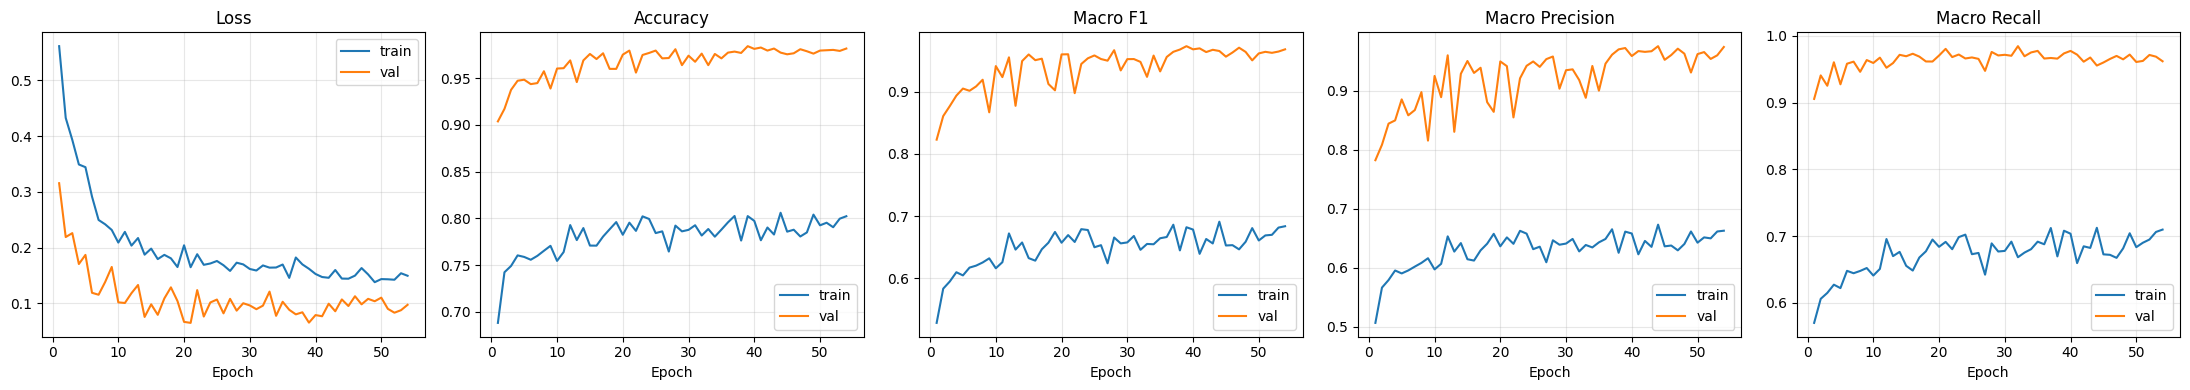

Saved: training_curves.png


In [18]:
# ── Cell 18 : Training curves ─────────────────────────────────────────
with open(HISTORY_PATH) as f:
    history = json.load(f)

tr = history["train"]
vl = history["val"]
epochs = range(1, len(tr) + 1)

keys   = ["loss", "acc", "f1", "prec", "rec"]
titles = ["Loss", "Accuracy", "Macro F1", "Macro Precision", "Macro Recall"]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, key, title in zip(axes, keys, titles):
    ax.plot(epochs, [m[key] for m in tr], label="train")
    ax.plot(epochs, [m[key] for m in vl], label="val")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "training_curves.png"), dpi=100)
plt.show()
print("Saved: training_curves.png")

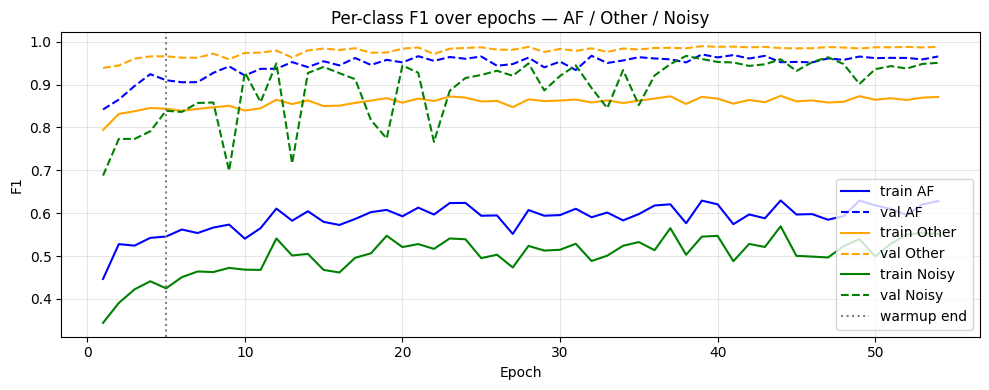

In [19]:
# ── Cell 19 : Per-class F1 over epochs ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(epochs, [m["f1_AF"] for m in tr], label="train AF",    color="blue")
ax.plot(epochs, [m["f1_AF"] for m in vl], label="val AF",      color="blue",   linestyle="--")
ax.plot(epochs, [m["f1_OT"] for m in tr], label="train Other", color="orange")
ax.plot(epochs, [m["f1_OT"] for m in vl], label="val Other",   color="orange", linestyle="--")
ax.plot(epochs, [m["f1_NO"] for m in tr], label="train Noisy", color="green")
ax.plot(epochs, [m["f1_NO"] for m in vl], label="val Noisy",   color="green",  linestyle="--")
ax.axvline(WARMUP_EPOCHS, color="gray", linestyle=":", label="warmup end")
ax.set_title("Per-class F1 over epochs — AF / Other / Noisy")
ax.set_xlabel("Epoch")
ax.set_ylabel("F1")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "per_class_f1.png"), dpi=100)
plt.show()

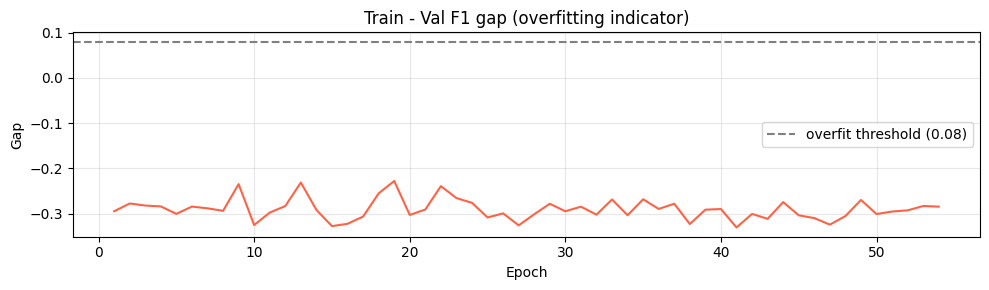

Max overfit gap: -0.2278  (no significant overfitting)


In [20]:
# ── Cell 20 : Overfitting gap ─────────────────────────────────────────
gap = [t["f1"] - v["f1"] for t, v in zip(tr, vl)]
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(epochs, gap, color="tomato")
ax.axhline(0.08, color="gray", linestyle="--", label="overfit threshold (0.08)")
ax.set_title("Train - Val F1 gap (overfitting indicator)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Gap")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "overfit_gap.png"), dpi=100)
plt.show()
print(f"Max overfit gap: {max(gap):.4f}"
      f"  {'(overfitting occurred)' if max(gap) > 0.08 else '(no significant overfitting)'}")

In [21]:
# ── Cell 21 : Final evaluation on val split ───────────────────────────
model.load_state_dict(torch.load(CKPT_MODEL, map_location=DEVICE))
model.eval()

all_preds, all_trues, all_probs = [], [], []
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(DEVICE)
        with torch.amp.autocast("cuda"):
            logits = forward_stage2(model, x)
        probs = F.softmax(logits, dim=1)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_trues.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_trues = np.array(all_trues)
all_probs = np.array(all_probs)

print("Classification report (best checkpoint, val split):")
print(classification_report(all_trues, all_preds,
      target_names=CLASS_NAMES, digits=4))

macro_f1 = f1_score(all_trues, all_preds, average="macro")
print(f"Val macro F1: {macro_f1:.4f}")

# Target check from Plan A
af_f1  = f1_score(all_trues, all_preds, labels=[0], average="macro")
ot_f1  = f1_score(all_trues, all_preds, labels=[1], average="macro")
no_f1  = f1_score(all_trues, all_preds, labels=[2], average="macro")
print(f"\nTarget check:")
print(f"  AF    F1: {af_f1:.4f}  {'✓ (target ≥ 0.80)' if af_f1 >= 0.80 else '✗ (target ≥ 0.80)'}")
print(f"  Other F1: {ot_f1:.4f}  {'✓ (target ≥ 0.70)' if ot_f1 >= 0.70 else '✗ (target ≥ 0.70)'}")
print(f"  Noisy F1: {no_f1:.4f}  {'✓ (target ≥ 0.80)' if no_f1 >= 0.80 else '✗ (target ≥ 0.80)'}")

Classification report (best checkpoint, val split):
              precision    recall  f1-score   support

      AF (A)     0.9709    0.9604    0.9656       556
   Other (O)     0.9856    0.9904    0.9880      2076
   Noisy (~)     0.9667    0.9355    0.9508       124

    accuracy                         0.9819      2756
   macro avg     0.9744    0.9621    0.9681      2756
weighted avg     0.9818    0.9819    0.9818      2756

Val macro F1: 0.9681

Target check:
  AF    F1: 0.9656  ✓ (target ≥ 0.80)
  Other F1: 0.9880  ✓ (target ≥ 0.70)
  Noisy F1: 0.9508  ✓ (target ≥ 0.80)


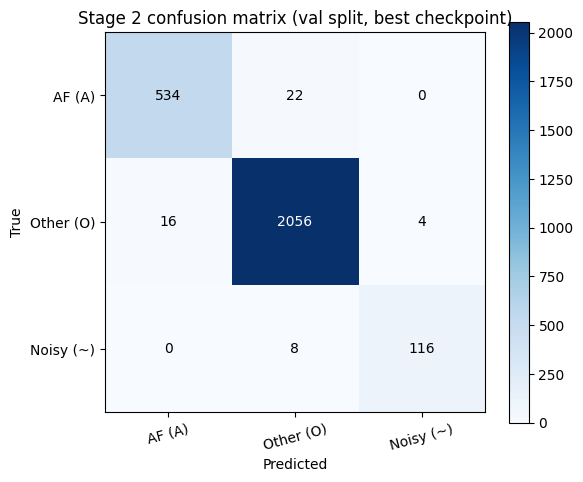

In [22]:
# ── Cell 22 : Confusion matrix ────────────────────────────────────────
cm  = confusion_matrix(all_trues, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
im  = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
ax.set_xticklabels(CLASS_NAMES, rotation=15)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Stage 2 confusion matrix (val split, best checkpoint)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "confusion_matrix.png"), dpi=100)
plt.show()

In [23]:
# ── Cell 23 : Save best threshold per class (for Phase 4) ────────────
# For 3-class, we save the argmax approach (no threshold sweep needed)
# but we also save the raw softmax confidence for Phase 4 to use
threshold_info = {
    "stage2_inference": "argmax",
    "class_map": {"0": "AF", "1": "Other", "2": "Noisy"},
    "val_macro_f1": float(macro_f1),
    "val_f1_AF":    float(af_f1),
    "val_f1_OT":    float(ot_f1),
    "val_f1_NO":    float(no_f1),
}
with open(os.path.join(CKPT_DIR, "stage2_info.json"), "w") as f:
    json.dump(threshold_info, f, indent=2)
print("Saved: stage2_info.json")


# ── Cell 24 : Summary
print("\n" + "="*60)
print("PHASE 2 PART 2 COMPLETE")
print("="*60)
print(f"\nBest val macro F1 : {best_val_f1:.4f}")
print(f"AF F1             : {af_f1:.4f}  (target ≥ 0.80)")
print(f"Other F1          : {ot_f1:.4f}  (target ≥ 0.70)")
print(f"Noisy F1          : {no_f1:.4f}  (target ≥ 0.80)")
print(f"\nFiles saved in: {CKPT_DIR}")
print("  best_model.pt       — Stage 2 weights")
print("  train_state.json    — epoch / F1 / patience / lr")
print("  history.json        — full per-epoch metrics")
print("  stage2_info.json    — val F1s and class map for Phase 4")
print("  training_curves.png")
print("  per_class_f1.png")
print("  overfit_gap.png")
print("  confusion_matrix.png")
print("\nProceed to Phase 3 — Hierarchical Inference.")

Saved: stage2_info.json

PHASE 2 PART 2 COMPLETE

Best val macro F1 : 0.9732
AF F1             : 0.9656  (target ≥ 0.80)
Other F1          : 0.9880  (target ≥ 0.70)
Noisy F1          : 0.9508  (target ≥ 0.80)

Files saved in: /kaggle/working/checkpoints_stage2
  best_model.pt       — Stage 2 weights
  train_state.json    — epoch / F1 / patience / lr
  history.json        — full per-epoch metrics
  stage2_info.json    — val F1s and class map for Phase 4
  training_curves.png
  per_class_f1.png
  overfit_gap.png
  confusion_matrix.png

Proceed to Phase 3 — Hierarchical Inference.
